In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# 7.01 — Cross-model validation by group: GLM-HMM ↔ DDM

Extends 7.00 by splitting cross-model correlations into **5 groups**:
HC, tremor_off, tremor_on, brady_off, brady_on.

The global signal (prior_idx ~ ddm_drift) is weak (r≈0.22) and vanishes within
broad subtype groups (7.00 results). Splitting by medication state tests whether
the dopaminergic manipulation (on vs off) modulates the coherence between models —
which would directly implicate the dopamine system in linking latent state usage
to the drift mechanism.

In [2]:
import pickle
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, spearmanr
from scipy.optimize import linear_sum_assignment

from imports import *
from config import dir_config
from src.shared_glm_hmm.grouping import session_metadata

def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

In [3]:
processed_dir = Path(dir_config.data.processed)
shared_dir    = processed_dir / "shared_glm_hmm"

_sel   = shared_dir / "selected_model.json"
CONFIG = json.loads(_sel.read_text())["config"]

# selected_model.json may lag behind actual directory names (e.g. XY_tgt vs XY__tgt).
# Walk sibling directories to find the best match if the exact path is missing.
if not (shared_dir / CONFIG / "all_subjects_final.pkl").exists():
    candidates = [
        d.name for d in shared_dir.iterdir()
        if d.is_dir() and (d / "all_subjects_final.pkl").exists()
        and d.name.replace("_", "") == CONFIG.replace("_", "")
    ]
    if candidates:
        CONFIG = sorted(candidates)[0]
        print(f"Resolved config → {CONFIG}")
    else:
        raise FileNotFoundError(
            f"Cannot find all_subjects_final.pkl for config '{CONFIG}' "
            f"under {shared_dir}. Available: {[d.name for d in shared_dir.iterdir() if d.is_dir()]}"
        )

bundle   = pickle.load(open(shared_dir / CONFIG / "all_subjects_final.pkl", "rb"))
pooled   = bundle["model"]["pooled"]
smodels  = bundle["model"]["models"]
feats    = bundle["config"]["model_features"]
K        = bundle["best_k"]
data     = bundle["data"]
ci, bi   = feats.index("color"), feats.index("bias")
ref_w    = -pooled.observations.params[:, 0, :]          # (K, M)
prior_state = int(np.argmax(ref_w[:, ci]))
state_names = {0: "Positive biased", 1: "Negative biased", 2: "Unbiased", 3: "Lapse"}

sess_md = session_metadata(
    pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
).set_index("session_id")

ddm = (
    pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60_ddm_params.csv")
    .drop_duplicates("session_id")
    .set_index("session_id")
)

print(f"CONFIG={CONFIG}  K={K}  prior_state=S{prior_state} "
      f"({state_names[prior_state]})  color wt={ref_w[prior_state, ci]:.3f}")

CONFIG=XY__tgt  K=4  prior_state=S1 (Negative biased)  color wt=0.334


## 1. Build session table (same as 7.00)

In [4]:
def align_perm(w, ref):
    cost = np.array([[np.sum((w[i] - ref[j])**2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost)
    inv = np.empty_like(col); inv[col] = np.arange(len(col))
    return inv

def session_post(model, df):
    obs = df["choices"].values.astype(int).reshape(-1, 1)
    inp = df[feats].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    return model.expected_states(data=obs, input=inp, mask=msk)[0], msk[:, 0]

def stationary(T):
    vals, vecs = np.linalg.eig(T.T)
    i = int(np.argmin(np.abs(vals - 1)))
    p = np.real(vecs[:, i]); return p / p.sum()

wb, wc = ref_w[:, bi], ref_w[:, ci]
rows = []
for sid, df in data.items():
    post, v = session_post(pooled, df)
    occ = post[v].mean(0)
    prior_idx = float(np.sum(occ * sigmoid(wb + wc)) - np.sum(occ * sigmoid(wb)))
    m = smodels[sid]; perm = align_perm(-m.observations.params[:, 0, :], ref_w)
    pi = stationary(m.transitions.transition_matrix[np.ix_(perm, perm)])
    rows.append(dict(session_id=sid, occ_prior=occ[prior_state],
                     prior_idx=prior_idx, pi_prior=pi[prior_state]))

g = pd.DataFrame(rows).set_index("session_id").join(sess_md)
g["ddm_drift_prior"]   = ddm["drift_offset_prior_cond_1"] - ddm["drift_offset_prior_cond_0"]
g["ddm_z_prior"]       = ddm["z_prior_cond_1"]            - ddm["z_prior_cond_0"]
g["ddm_drift_unequal"] = ddm["drift_offset_prior_cond_1"]
g["ddm_z_unequal"]     = ddm["z_prior_cond_1"]

# 5-group label: HC | tremor_off | tremor_on | brady_off | brady_on
def make_group(row):
    s, m = row["subtype"], row["medication"]
    if s == "HC":           return "HC"
    if s == "tremor":       return f"tremor_{m}"
    if s == "bradykinetic": return f"brady_{m}"
    return None  # intermediate dropped

g["group"] = g.apply(make_group, axis=1)
g = g[g["group"].notna()]

GROUP_ORDER = ["HC", "tremor_off", "tremor_on", "brady_off", "brady_on"]
print("session table:", g.shape)
print(g["group"].value_counts()[GROUP_ORDER])

session table: (60, 12)
group
HC            18
tremor_off    11
tremor_on     11
brady_off     10
brady_on      10
Name: count, dtype: int64


## 2. Group-specific correlations

Compute the same six correlation pairs as 7.00 within each of the 5 groups.

Key predictions:
- If dopamine restores prior-drift coherence: **on > off** correlation for both PD subtypes
- If tremor and bradykinetic differ mechanistically: one subtype should show on/off modulation, the other should not
- z channel should remain null in all groups

In [5]:
PAIRS = [
    ("prior_idx", "ddm_drift_prior"),
    ("occ_prior",  "ddm_drift_prior"),
    ("prior_idx", "ddm_z_prior"),
    ("occ_prior",  "ddm_z_prior"),
    ("pi_prior",   "ddm_z_prior"),
    ("pi_prior",   "ddm_drift_prior"),
]

def corr_group(df, a, b):
    d = df[[a, b]].dropna()
    n = len(d)
    if n < 5:
        return dict(n=n, pearson_r=np.nan, pearson_p=np.nan,
                    spearman_r=np.nan, spearman_p=np.nan)
    r,  p  = pearsonr(d[a],  d[b])
    rs, ps = spearmanr(d[a], d[b])
    return dict(n=n,
                pearson_r=round(r,  3), pearson_p=round(p,  4),
                spearman_r=round(rs, 3), spearman_p=round(ps, 4))

records = []
for grp in GROUP_ORDER:
    sg = g[g["group"] == grp]
    for (a, b) in PAIRS:
        row = corr_group(sg, a, b)
        row.update(group=grp, x=a, y=b)
        records.append(row)

# pooled ALL row for reference
for (a, b) in PAIRS:
    row = corr_group(g, a, b)
    row.update(group="ALL", x=a, y=b)
    records.append(row)

ctab = pd.DataFrame(records)[["group","x","y","n",
                               "pearson_r","pearson_p",
                               "spearman_r","spearman_p"]]
print("Group-specific cross-model correlations:")
ctab

Group-specific cross-model correlations:


,group,x,y,n,pearson_r,pearson_p,spearman_r,spearman_p
0,HC,prior_idx,ddm_drift_prior,18,-0.192,0.4459,-0.022,0.9320
1,HC,occ_prior,ddm_drift_prior,18,0.145,0.5664,0.267,0.2836
2,HC,prior_idx,ddm_z_prior,18,-0.455,0.0579,-0.441,0.0672
3,HC,occ_prior,ddm_z_prior,18,-0.349,0.1560,-0.350,0.1547
4,HC,pi_prior,ddm_z_prior,18,0.610,0.0071,0.461,0.0540
5,HC,pi_prior,ddm_drift_prior,18,0.303,0.2218,-0.123,0.6273
6,tremor_off,prior_idx,ddm_drift_prior,11,0.089,0.7945,0.227,0.5015
7,tremor_off,occ_prior,ddm_drift_prior,11,0.267,0.4269,-0.045,0.8944
8,tremor_off,prior_idx,ddm_z_prior,11,-0.096,0.7788,-0.173,0.6115
9,tremor_off,occ_prior,ddm_z_prior,11,0.562,0.0722,0.609,0.0467


## 3. Pivot summary — Pearson r by group

Focusing on the two key pairs (prior_idx ~ drift, prior_idx ~ z) to read
the dissociation pattern within each group at a glance.

In [6]:
key_pairs = [
    ("prior_idx", "ddm_drift_prior", "prior_idx ~ drift"),
    ("occ_prior",  "ddm_drift_prior", "occ_prior ~ drift"),
    ("prior_idx", "ddm_z_prior",     "prior_idx ~ z"),
    ("occ_prior",  "ddm_z_prior",    "occ_prior ~ z"),
    ("pi_prior",   "ddm_z_prior",    "pi_prior  ~ z"),
]

col_order = ["ALL"] + GROUP_ORDER
pivot_r, pivot_p = {}, {}
for (a, b, label) in key_pairs:
    pivot_r[label], pivot_p[label] = {}, {}
    for grp in col_order:
        row = ctab[(ctab.group == grp) & (ctab.x == a) & (ctab.y == b)]
        if len(row):
            pivot_r[label][grp] = row.iloc[0]["pearson_r"]
            pivot_p[label][grp] = row.iloc[0]["pearson_p"]

df_r = pd.DataFrame(pivot_r).T[col_order]
df_p = pd.DataFrame(pivot_p).T[col_order]

def annotate(r, p):
    if pd.isna(r): return "—"
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    return f"{r:.2f}{stars}"

df_ann = pd.DataFrame(
    {col: [annotate(df_r.loc[row, col], df_p.loc[row, col]) for row in df_r.index]
     for col in df_r.columns},
    index=df_r.index
)
print("Pearson r  (* p<.05  ** p<.01  *** p<.001)")
df_ann

Pearson r  (* p<.05  ** p<.01  *** p<.001)


,ALL,HC,tremor_off,tremor_on,brady_off,brady_on
prior_idx ~ drift,0.04,-0.19,0.09,0.03,0.39,-0.23
occ_prior ~ drift,0.12,0.14,0.27,-0.04,0.59,-0.30
prior_idx ~ z,-0.18,-0.46,-0.10,-0.16,0.03,0.02
occ_prior ~ z,-0.02,-0.35,0.56,-0.07,-0.10,0.34
pi_prior ~ z,0.05,0.61**,0.12,-0.29,0.09,-0.01


## 4. Group scatter plots

One row per subtype, four panels per row matching 7.00:
`prior_idx ~ drift` | `occ_prior ~ drift` | `prior_idx ~ z` | `pi_prior ~ z`

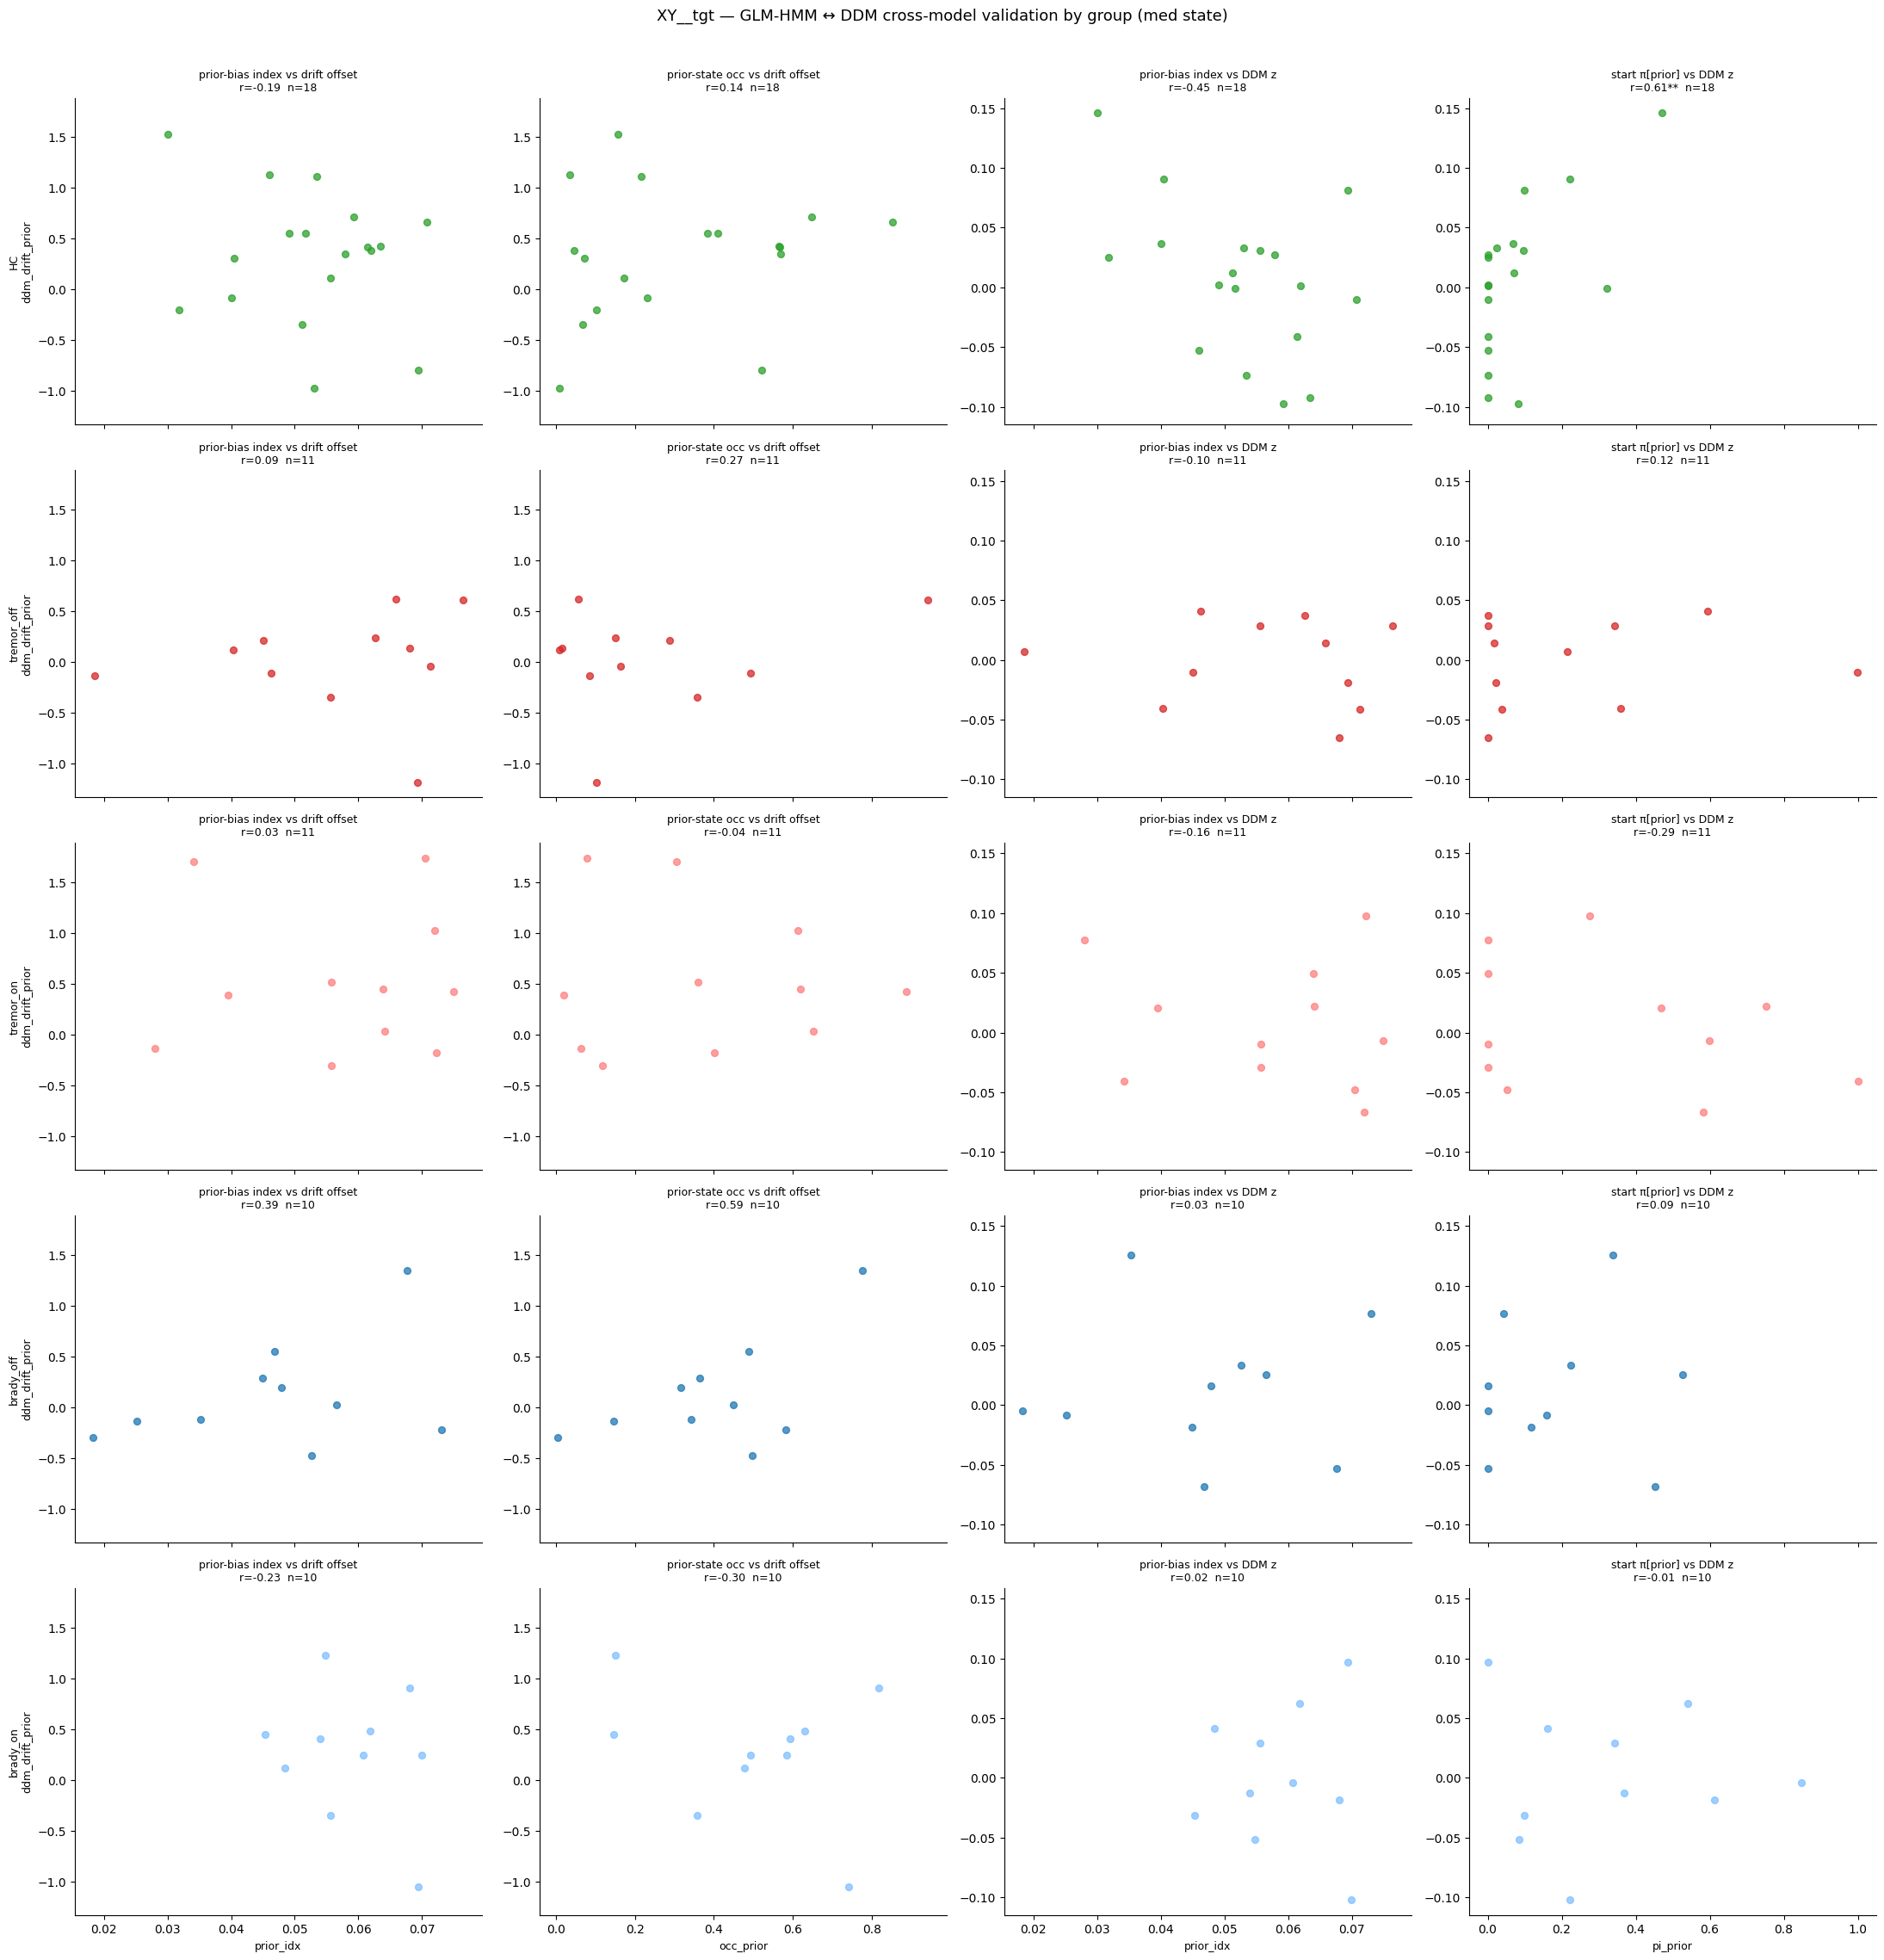

In [7]:
cmap = {
    "HC":         "tab:green",
    "tremor_off": "#d62728",   # dark red
    "tremor_on":  "#ff7f7f",   # light red
    "brady_off":  "#1f77b4",   # dark blue
    "brady_on":   "#7fbfff",   # light blue
}
panels = [
    ("prior_idx", "ddm_drift_prior", "prior-bias index vs drift offset"),
    ("occ_prior",  "ddm_drift_prior", "prior-state occ vs drift offset"),
    ("prior_idx", "ddm_z_prior",     "prior-bias index vs DDM z"),
    ("pi_prior",   "ddm_z_prior",    "start π[prior] vs DDM z"),
]

fig, axes = plt.subplots(
    len(GROUP_ORDER), len(panels),
    figsize=(22, 4.5 * len(GROUP_ORDER)),
    sharex="col", sharey="col"
)

for ri, grp in enumerate(GROUP_ORDER):
    sg = g[g["group"] == grp]
    for ci_, (x, y, title) in enumerate(panels):
        ax = axes[ri, ci_]
        d  = sg[[x, y]].dropna()
        ax.scatter(d[x], d[y], s=32, alpha=0.75, color=cmap[grp])
        if len(d) >= 5:
            r, p = pearsonr(d[x], d[y])
            stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            ax.set_title(f"{title}\nr={r:.2f}{stars}  n={len(d)}", fontsize=9)
        else:
            ax.set_title(f"{title}\nn={len(d)} (too few)", fontsize=9)
        if ri == len(GROUP_ORDER) - 1:
            ax.set_xlabel(x, fontsize=9)
        if ci_ == 0:
            ax.set_ylabel(f"{grp}\n{y}", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"{CONFIG} — GLM-HMM ↔ DDM cross-model validation by group (med state)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation r comparison across groups (bar chart)

Plot Pearson r for `prior_idx ~ ddm_drift_prior` side-by-side per group,
with error bars from Fisher-z bootstrap to see if groups differ.

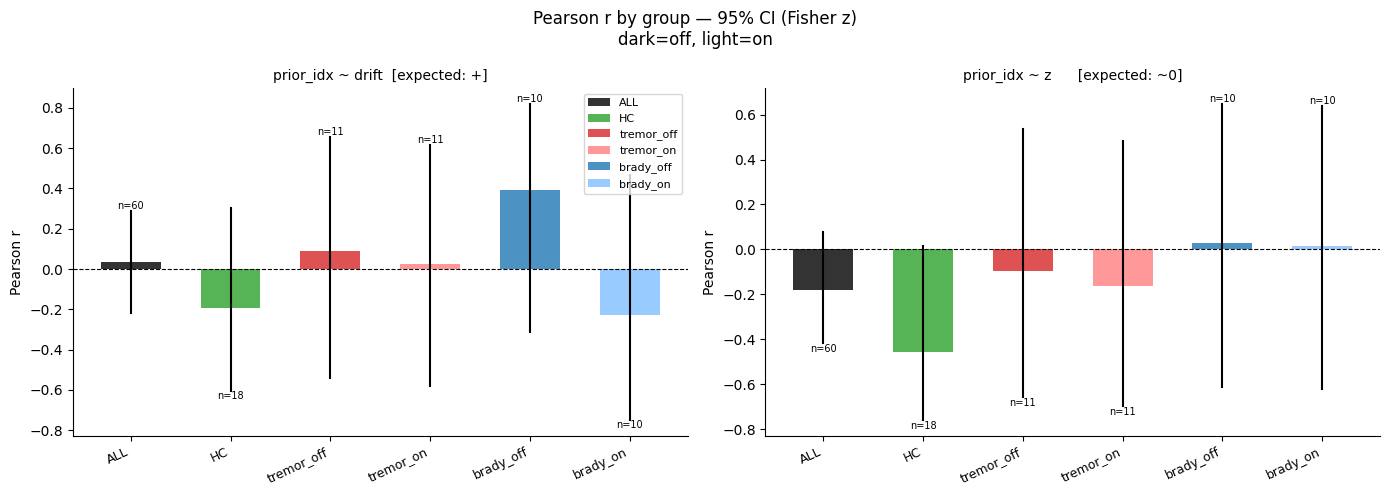

In [8]:
from scipy.stats import norm as _norm

def fisher_ci(r, n, alpha=0.05):
    """95% CI for Pearson r via Fisher z-transform."""
    if np.isnan(r) or n < 4:
        return np.nan, np.nan
    z  = np.arctanh(r)
    se = 1.0 / np.sqrt(n - 3)
    zc = _norm.ppf(1 - alpha / 2)
    return np.tanh(z - zc * se), np.tanh(z + zc * se)

focus_pairs = [
    ("prior_idx", "ddm_drift_prior", "prior_idx ~ drift  [expected: +]"),
    ("prior_idx", "ddm_z_prior",     "prior_idx ~ z      [expected: ~0]"),
]

bar_groups = ["ALL"] + GROUP_ORDER
bar_colors = ["black", cmap["HC"], cmap["tremor_off"], cmap["tremor_on"],
              cmap["brady_off"], cmap["brady_on"]]

fig, axes = plt.subplots(1, len(focus_pairs), figsize=(14, 5), sharey=False)

for ax, (a, b, label) in zip(axes, focus_pairs):
    for i, (grp, c) in enumerate(zip(bar_groups, bar_colors)):
        row = ctab[(ctab.group == grp) & (ctab.x == a) & (ctab.y == b)]
        if len(row) == 0: continue
        r = row.iloc[0]["pearson_r"]
        n = int(row.iloc[0]["n"])
        if np.isnan(r): continue
        lo, hi = fisher_ci(r, n)
        ax.bar(i, r, color=c, alpha=0.8, width=0.6, label=grp)
        ax.plot([i, i], [lo, hi], color="black", lw=1.5)
        ax.text(i, (hi if r >= 0 else lo) + (0.01 if r >= 0 else -0.04),
                f"n={n}", ha="center", fontsize=7)

    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xticks(range(len(bar_groups)))
    ax.set_xticklabels(bar_groups, rotation=25, ha="right", fontsize=9)
    ax.set_ylabel("Pearson r")
    ax.set_title(label, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Pearson r by group — 95% CI (Fisher z)\ndark=off, light=on", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Read-out

**What to look for:**

- **on > off within PD subtypes** on `prior_idx ~ drift`: dopamine restores the coherence
  between latent-state prior usage and DDM drift — implicating the dopaminergic system
  specifically in coupling state switching to the evidence accumulation mechanism.

- **off > on** would suggest medication suppresses the correlation — less expected but
  possible if levodopa over-corrects and disrupts state stability.

- **Tremor vs. bradykinetic asymmetry**: a medication effect in one subtype but not the
  other would separate dopaminergic (bradykinetic) from non-dopaminergic (tremor) pathways.

- **z channel remains null across all groups**: confirms the dissociation is robust to
  the medication split and not a grouping artefact.

**Caution:** n ≈ 10–11 per group makes within-group correlations very underpowered.
The Fisher z-test (Section 7) is the appropriate test for on vs. off differences;
visual patterns in the scatter plots are suggestive only.

In [9]:
from scipy.stats import norm as _norm

def fisher_z_test(r1, n1, r2, n2):
    """Two-sided test: H0: rho1 == rho2."""
    if any(np.isnan(v) or v < 4 for v in [n1, n2]) or np.isnan(r1) or np.isnan(r2):
        return np.nan, np.nan
    z  = (np.arctanh(r1) - np.arctanh(r2)) / np.sqrt(1/(n1-3) + 1/(n2-3))
    p  = 2 * (1 - _norm.cdf(abs(z)))
    return round(z, 3), round(p, 4)

def lookup(grp, a, b):
    row = ctab[(ctab.group == grp) & (ctab.x == a) & (ctab.y == b)]
    if not len(row): return np.nan, 0
    return row.iloc[0]["pearson_r"], int(row.iloc[0]["n"])

print("Fisher z-tests: on vs off within each PD subtype  (prior_idx ~ ddm_drift_prior)")
print(f"{'Comparison':<35} {'r_off':>6} {'r_on':>6}  {'z':>6}  {'p':>8}")
print("-" * 65)
for subtype, off_grp, on_grp in [("tremor",       "tremor_off", "tremor_on"),
                                   ("bradykinetic", "brady_off",  "brady_on")]:
    r_off, n_off = lookup(off_grp, "prior_idx", "ddm_drift_prior")
    r_on,  n_on  = lookup(on_grp,  "prior_idx", "ddm_drift_prior")
    z, p = fisher_z_test(r_off, n_off, r_on, n_on)
    stars = "*" if not np.isnan(p) and p < 0.05 else ""
    print(f"{off_grp}(n={n_off}) vs {on_grp}(n={n_on}):  "
          f"r={r_off:.3f}  r={r_on:.3f}   z={z!s:>6}  p={p!s:>8} {stars}")

print()
print("Fisher z-tests: HC vs each group  (prior_idx ~ ddm_drift_prior)")
print(f"{'Comparison':<40} {'r_HC':>6} {'r_grp':>6}  {'z':>6}  {'p':>8}")
print("-" * 70)
r_hc, n_hc = lookup("HC", "prior_idx", "ddm_drift_prior")
for grp in ["tremor_off", "tremor_on", "brady_off", "brady_on"]:
    r_g, n_g = lookup(grp, "prior_idx", "ddm_drift_prior")
    z, p = fisher_z_test(r_hc, n_hc, r_g, n_g)
    stars = "*" if not np.isnan(p) and p < 0.05 else ""
    print(f"HC(n={n_hc}) vs {grp}(n={n_g}):  "
          f"r={r_hc:.3f}  r={r_g:.3f}   z={z!s:>6}  p={p!s:>8} {stars}")

Fisher z-tests: on vs off within each PD subtype  (prior_idx ~ ddm_drift_prior)
Comparison                           r_off   r_on       z         p
-----------------------------------------------------------------
tremor_off(n=11) vs tremor_on(n=11):  r=0.089  r=0.027   z= 0.124  p=   0.901 
brady_off(n=10) vs brady_on(n=10):  r=0.393  r=-0.229   z= 1.213  p=  0.2251 

Fisher z-tests: HC vs each group  (prior_idx ~ ddm_drift_prior)
Comparison                                 r_HC  r_grp       z         p
----------------------------------------------------------------------
HC(n=18) vs tremor_off(n=11):  r=-0.192  r=0.089   z=-0.648  p=   0.517 
HC(n=18) vs tremor_on(n=11):  r=-0.192  r=0.027   z=-0.506  p=   0.613 
HC(n=18) vs brady_off(n=10):  r=-0.192  r=0.393   z=-1.332  p=  0.1828 
HC(n=18) vs brady_on(n=10):  r=-0.192  r=-0.229   z= 0.085  p=  0.9326 
